In [39]:
ge_freq = 8.02e9 + 0.0018e9 
ef_freq = 7.71e9
anharmonicity = ef_freq -ge_freq

readout_freq = 10.3e9

2 * ge_freq + anharmonicity- readout_freq

5431800000.0

In [81]:
readout_freq = 9.23e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

qubit_lo_freq = 7.92543e9
ge_freq = 8.02e9 + 0.0027e9
ge_if_freq =ge_freq - qubit_lo_freq
ef_freq = 7.7e9 + 1.096e4#7.86e9 #7.71e9
ef_if_freq = ef_freq - qubit_lo_freq

fogi_lo_freq = 2 * qubit_lo_freq - readout_freq - readout_if_freq
fogi_lo_freq

6495860000.0

## 7/2 ef calibration

ef_freq =  7.7e9

ef_pi_amp = 0.67


T1 = 1.5185567636518252e-05 (1.3579023125076383e-05)

T2 =

T2_star = 

In [2]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [3]:
import sklearn
from sklearn.decomposition import PCA

In [4]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

amp

In [5]:
header = "D:/K_sunada/database/"
ef = "/2023-07-18/2023-07-18T153115_b2913a76-td_ef_pi_amp"
dd_ef = datadict_from_hdf5(header + ef +"/data")

In [6]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [7]:
Rabi_ef = dd_ef['s11']['values']
#imag_ge = Rabi_ge.imag
amp_ef = dd_ef['amplitude']['values']

I = (Rabi_ef.real)
Q = (Rabi_ef.imag)

PCAef = PCA_transform(I, Q)

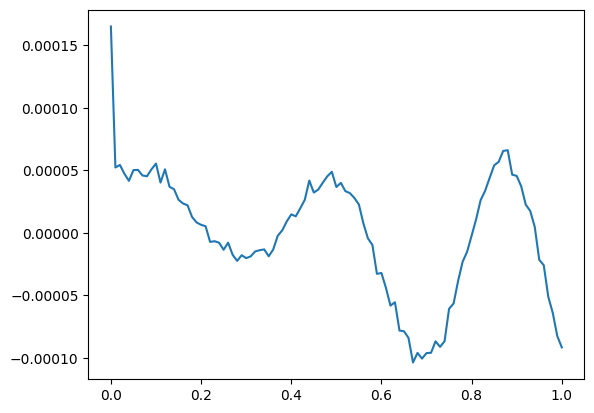

In [8]:
y = PCAef[0]
x = amp_ef

plt.plot(x, y)
plt.show()

In [17]:
par_ini = {
    'amp': 0.0001,
    'phi0':np.pi/2,
    'detun':1/0.5,
    'const':0
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [18]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [19]:
result_ef = model.fit(data = y, params = params, delay = x)
result_ef

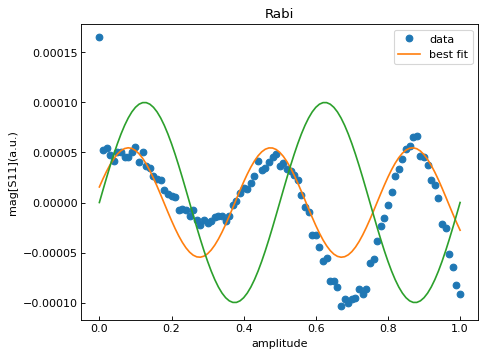

In [20]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_ef.plot_fit(ax = ax)
plt.plot(amp_ef,result_ef.init_fit)

plt.xlabel("amplitude")
plt.ylabel("mag[S11](a.u.)")


plt.show()

In [21]:
np.pi/(2.53863422	*2*np.pi)*5

0.9847814940428874

ramsey

In [22]:
pl = "/2023-07-18/2023-07-18T153719_8b4c8928-td_ef_T2r1d"
mi = "/2023-07-18/2023-07-18T153937_ddc4de70-td_ef_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

In [23]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

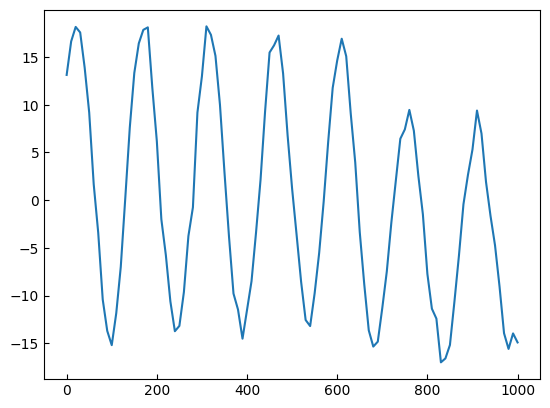

In [24]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2


I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)


PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi



plt.plot(x_pl, y_pl)
plt.show()

In [25]:
par_ini_pl = {
    'amp': 15,
    'phi0':0,
    'detun':1/180,
    'const':0
}

par_min_pl = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_pl = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_pl = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [26]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_pl[name],
    min = par_min_pl[name],
    max = par_max_pl[name],
    vary = par_vary_pl[name]
    )
    
result_pl = model.fit(data = y_pl, params = params, delay = x_pl)
result_pl

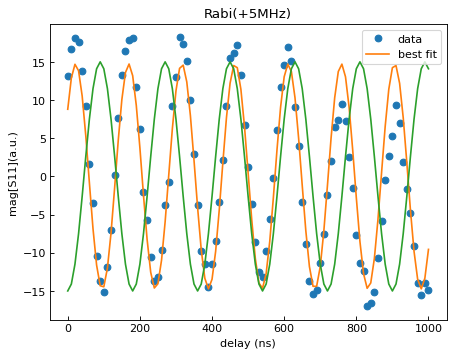

In [27]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(+5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax)
plt.plot(x_pl,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

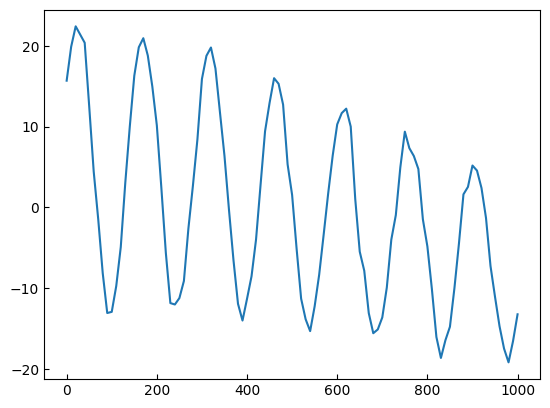

In [28]:
plt.plot(x_mi, y_mi)
plt.show()

In [29]:
par_ini_mi = {
    'amp': 15,
    'phi0':0,
    'detun':1/180,
    'const':0
}

par_min_mi = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_mi = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_mi = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [30]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_mi[name],
    min = par_min_mi[name],
    max = par_max_mi[name],
    vary = par_vary_mi[name]
    )
    
result_mi = model.fit(data = y_mi, params = params, delay = x_mi)
result_mi

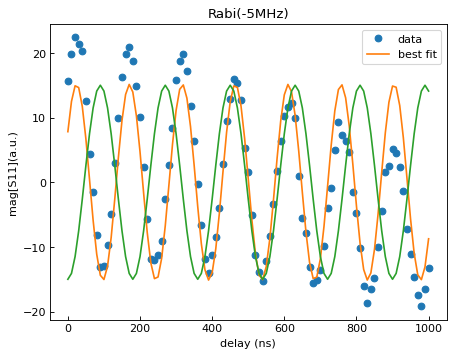

In [31]:


fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(x_mi,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()


In [32]:
detun = ((0.005-0.00678573)+ (0.00681560-0.005))/2 #GHz
detun

1.4934999999999775e-05

T1

In [33]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2023-07-18/2023-07-18T154400_7a06af44-td_ef_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

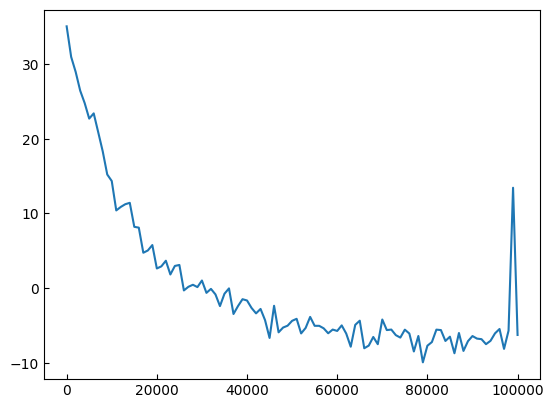

In [34]:
s11_t1 = dd_t1['s11']['values']
imag_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values']

I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)

PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

plt.plot(x_t1, y_t1)
plt.show()

In [35]:
par_ini_t1 = {
    'gamma': 1/20000,
    'amp':40,
    'const':-5
}

par_min_t1 = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t1 = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t1 = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [36]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1)
result_t1

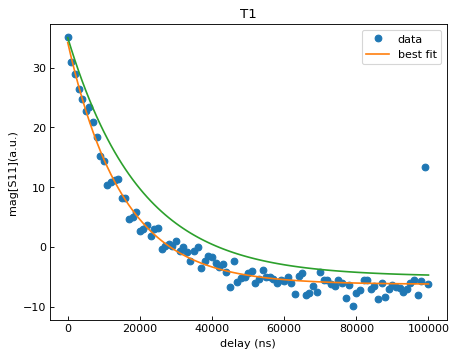

In [37]:
fig, ax = plt.subplots(dpi=80)

plt.title("T1")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
plt.plot(delay_t1,result_t1.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [38]:
T1 = (1/6.5852e-05)*1e-9	
T1

1.5185567636518252e-05

## no data

T2_star

In [59]:
t2e = "/2023-07-01/2023-07-01T181335_8e8e04ba-td_ge_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

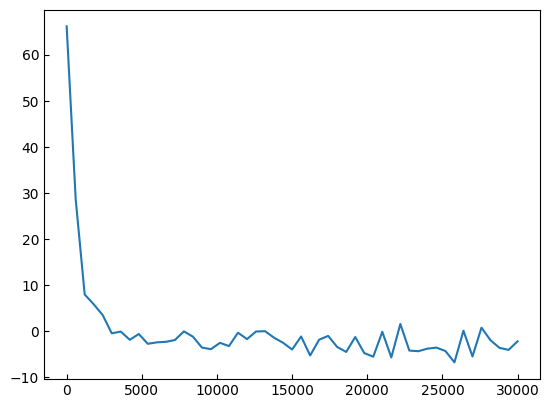

In [60]:
s11_t2e = dd_t2e['s11']['values']
imag_t2e = s11_t2e.imag
delay_t2e = dd_t2e['delay']['values']

I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)

PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e

plt.plot(x_t2e, y_t2e)
plt.show()

In [61]:
par_ini_t2e = {
    'gamma': 1/2000,
    'amp':70,
    'const':0
}

par_min_t2e = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t2e = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t2e = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [62]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e)
result_t2e

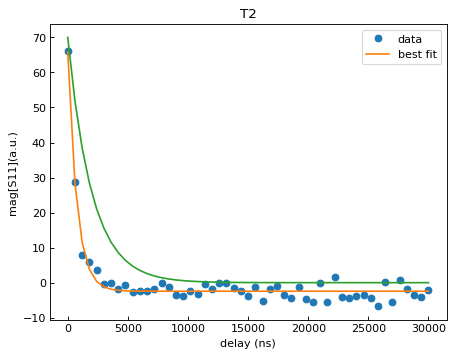

In [63]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
plt.plot(delay_t2e,result_t2e.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [64]:
T2 = (1/0.00132869)*1e-9	
T2

7.526210026416998e-07

T2 star

In [66]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

In [67]:
t2 = "/2023-07-01/2023-07-01T182745_892e135d-td_ge_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

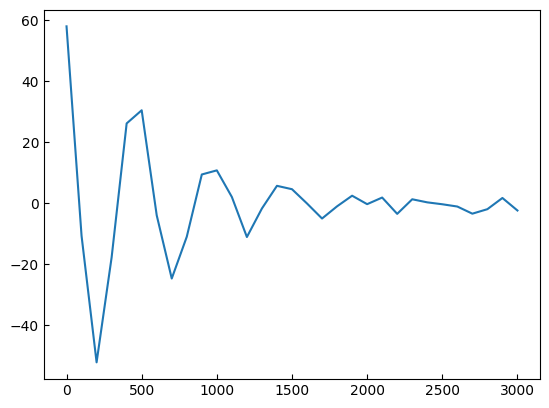

In [68]:
s11_t2 = dd_t2['s11']['values']
imag_t2 = s11_t2.imag
delay_t2 = dd_t2['delay']['values']

I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)

PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [69]:
par_ini_t2 = {
    'amp':60,
    'gamma': 1/1500,
    'omega':2*np.pi/500,
    'phi0':0,
    'const':0
}

par_min_t2 = {
    'amp':-np.inf,
    'gamma': 0,
    'omega':-2*np.pi,
    'phi0':-2*np.pi,
    'const':-np.inf
}

par_max_t2 = {
    'amp':np.inf,
    'gamma': np.inf,
    'omega':2*np.pi,
    'phi0':2*np.pi,
    'const':np.inf
}

par_vary_t2 = {
    'amp':True,
    'gamma': True,
    'omega':True,
    'phi0':True,
    'const':True
}

In [73]:
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2[name],
    min = par_min_t2[name],
    max = par_max_t2[name],
    vary = par_vary_t2[name]
    )
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2)
result_t2

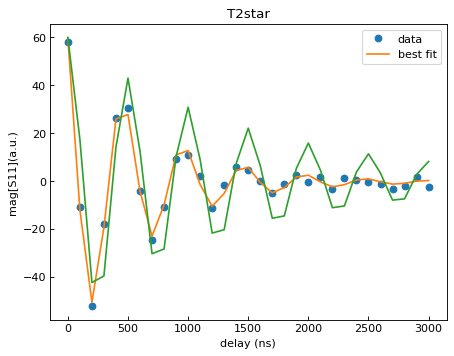

In [74]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2star")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
plt.plot(delay_t2,result_t2.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [75]:
T2_star = (1/0.00157781	)*1e-9	
T2_star

6.337898733054044e-07